In [ ]:
import mitsuba as mi
mi.set_variant("llvm_ad_rgb")

import drjit as dr
print("✅ Dr.Jit syntax available:", hasattr(dr, "syntax"))

✅ Dr.Jit syntax available: True


In [ ]:
"""
Factory RT simulation – current development version

NOTE:
- Geometry is finalized (Factory.xml)
- Ray-tracing pipeline is functional
- TX/RX and camera positions are provisional
- Placement refinement is ongoing

Purpose of this script:
- Demonstrate Sionna RT integration
- Show path computation, CIR extraction, and visualization
"""


In [ ]:
import mitsuba as mi
mi.set_variant("llvm_ad_rgb")

from sionna.rt import load_scene
scene = load_scene("/home/fidal/Factory.xml")

In [ ]:
import mitsuba as mi
mi.set_variant("llvm_ad_rgb")

from sionna.rt import Scene

In [ ]:
# ✅ Now load sionna.rt safely
import sionna.rt
print("✅ Fully patched: Sionna RT loaded cleanly with llvm_ad_rgb!")

✅ Fully patched: Sionna RT loaded cleanly with llvm_ad_rgb!


In [ ]:
# Other imports
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

no_preview = True # Toggle to False to use the preview widget

# Import relevant components from Sionna RT
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies

In [ ]:
from sionna.rt import load_scene

scene = load_scene("/home/fidal/Factory.xml")

In [ ]:
if not no_preview:
    scene.preview();

In [ ]:
with open("/home/fidal/Factory.xml", "r", encoding="utf-8") as f:
    lines = f.readlines()

for i, line in enumerate(lines):
    if "value=" in line and "," in line:
        try:
            value_part = line.split("value=")[1].split("\"")[1]
            numbers = [x.strip() for x in value_part.split(",")]
            if len(numbers) == 4:
                print(f"⚠️ Line {i+1}: {line.strip()}")
        except IndexError:
            print(f"⚠️ Skipped malformed line {i+1}: {line.strip()}")

In [ ]:
from sionna.rt import Camera

# Create camera with only required arguments
my_cam = Camera(
    position=[10,0,0],
    look_at=[-0.25,1,0.28]
)

# Set optional attributes manually
my_cam.up = [0.0, 0.0, 1.0]       # Z-axis up
my_cam.fov = 45                   # Field of view
my_cam.resolution = (600, 400)   # Output image resolution

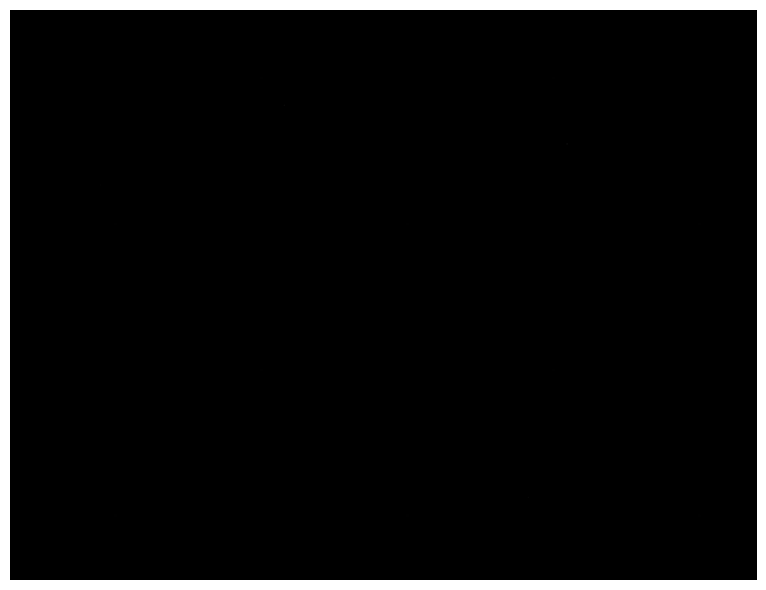

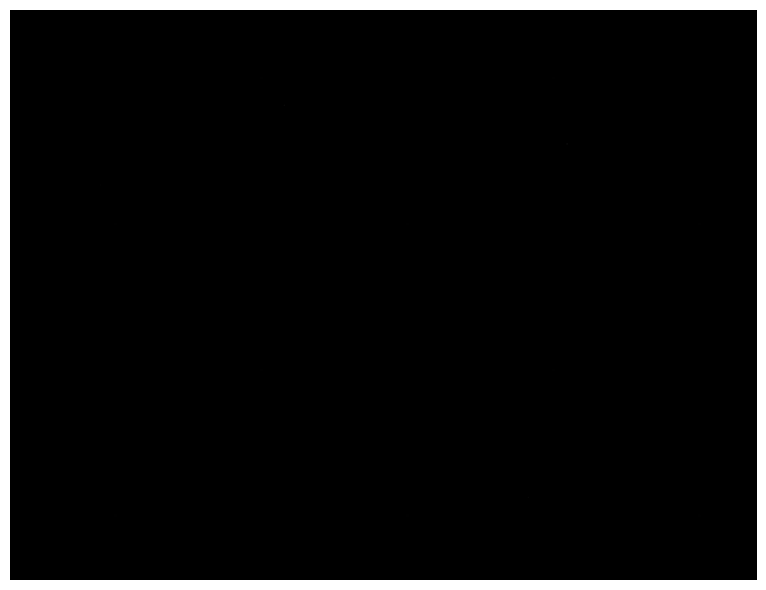

In [ ]:
# Render scene with new camera*
image = scene.render(camera=my_cam, num_samples=64, show_devices=False)
from IPython.display import display
display(image)

In [ ]:
scene.preview()


In [ ]:
print("Scene objects:", scene.objects)
print("Camera position:", my_cam.position)
print("Looking at:", my_cam.look_at)

Scene objects: {'no-name-5': <sionna.rt.scene_object.SceneObject object at 0x75a5fafc9780>, 'office': <sionna.rt.scene_object.SceneObject object at 0x75a5fafc9990>, 'no-name-6': <sionna.rt.scene_object.SceneObject object at 0x75a5fafcbfd0>, 'no-name-7': <sionna.rt.scene_object.SceneObject object at 0x75a5fafc9720>, 'no-name-8': <sionna.rt.scene_object.SceneObject object at 0x75a5fafc9ab0>}
Camera position: [[10, 0, 0]]
Looking at: <bound method Camera.look_at of <sionna.rt.camera.Camera object at 0x75a65b653dc0>>


In [ ]:
scene = load_scene(sionna.rt.scene.simple_street_canyon, merge_shapes=False)
scene.objects

{'building_1': <sionna.rt.scene_object.SceneObject at 0x75a5faf91840>,
 'building_6': <sionna.rt.scene_object.SceneObject at 0x75a5faf91660>,
 'building_5': <sionna.rt.scene_object.SceneObject at 0x75a5faf91870>,
 'building_4': <sionna.rt.scene_object.SceneObject at 0x75a5faf938e0>,
 'building_3': <sionna.rt.scene_object.SceneObject at 0x75a5faf935b0>,
 'building_2': <sionna.rt.scene_object.SceneObject at 0x75a5faf93550>,
 'floor': <sionna.rt.scene_object.SceneObject at 0x75a5faf93430>}

In [ ]:
floor = scene.get("floor")

In [ ]:
print("Position (x,y,z) [m]: ", floor.position)
print("Orientation (alpha, beta, gamma) [rad]: ", floor.orientation)
print("Scaling: ", floor.scaling)

Position (x,y,z) [m]:  [[-0.769669, 0.238537, -0.0307941]]
Orientation (alpha, beta, gamma) [rad]:  [[0, 0, 0]]
Scaling:  [[1, 1, 1]]


In [ ]:
print("Velocity (x,y,z) [m/s]: ", floor.velocity)

Velocity (x,y,z) [m/s]:  [[0, 0, 0]]


In [ ]:
floor.radio_material

ITURadioMaterial type=concrete
                 eta_r=5.240
                 sigma=0.123
                 thickness=0.100
                 scattering_coefficient=0.000
                 xpd_coefficient=0.000

In [ ]:
scene.frequency = 28e9 # in Hz; implicitly updates RadioMaterials that implement frequency dependent properties
floor.radio_material # Note that the conductivity (sigma) changes automatically

ITURadioMaterial type=concrete
                 eta_r=5.240
                 sigma=0.626
                 thickness=0.100
                 scattering_coefficient=0.000
                 xpd_coefficient=0.000

In [ ]:
from sionna.rt import load_scene

scene = load_scene("/home/fidal/Factory.xml")

# Configure antenna array for all transmitters
scene.tx_array = PlanarArray(num_rows=4,
                             num_cols=4,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="tr38901",
                             polarization="V")

# Configure antenna array for all receivers
scene.rx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="dipole",
                             polarization="cross")

# Create transmitter
tx = Transmitter(name="tx",
                 position=[4.769,0.311,10],
                 display_radius=2)

# Add transmitter instance to scene
scene.add(tx)

# Create a receiver
rx = Receiver(name="rx",
              position=[0.759,0.256,-7],
              display_radius=2)

# Create a receiver
rx = Receiver(name="rx",
              position=[20.302,-0.216,-7],
              display_radius=2)

# Add receiver instance to scene
scene.add(rx)

tx.look_at(rx) # Transmitter points towards receiver

In [ ]:
print("TX:", tx.position)
print("RX:", rx.position)

TX: [[4.769, 0.311, 10]]
RX: [[20.302, -0.216, -7]]


In [ ]:
# Instantiate a path solver
# The same path solver can be used with multiple scenes
p_solver  = PathSolver()

# Compute propagation paths
paths = p_solver(scene=scene,
                 max_depth=5,
                 los=True,
                 specular_reflection=True,
                 diffuse_reflection=True,
                 refraction=True,
                 synthetic_array=False,
                 seed=41)

⚠️ spectrum_to_matrix_4f: non-polarized Spectrum, using identity Jones fallback: drjit.llvm.ad.Float does not have a 'x' component.


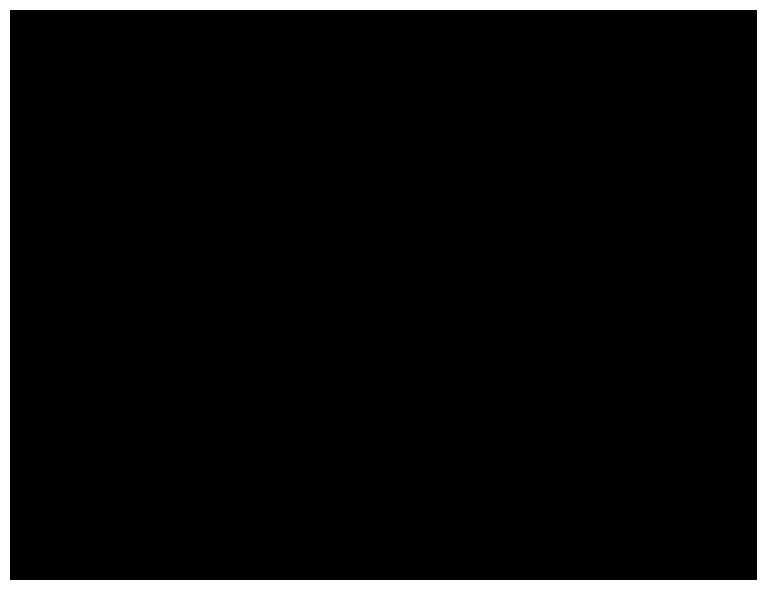

In [ ]:
if paths is not None:
    scene.render(camera=my_cam, paths=paths, show_devices=True)
else:
    print("❌ No valid propagation paths found for this scene slice.")
    scene.render(camera=my_cam, show_devices=True)

In [ ]:
a, tau = paths.cir(normalize_delays=True, out_type="numpy")

# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths, num_time_steps]
print("Shape of a: ", a.shape)

# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths]
print("Shape of tau: ", tau.shape)

Shape of a:  (1, 2, 1, 16, 1, 1)
Shape of tau:  (1, 2, 1, 16, 1)


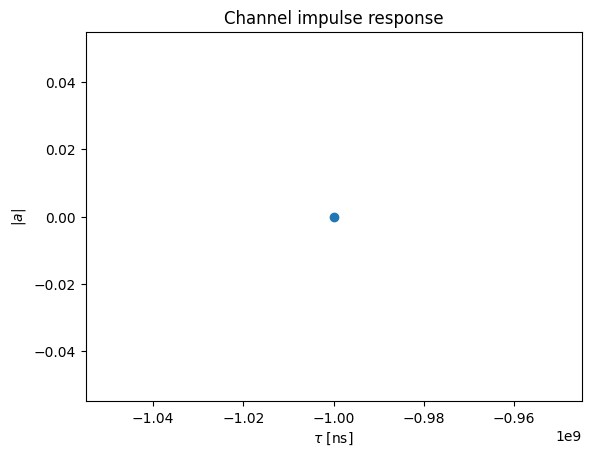

In [ ]:
t = tau[0,0,0,0,:]/1e-9 # Scale to ns
a_abs = np.abs(a)[0,0,0,0,:,0]
a_max = np.max(a_abs)

# And plot the CIR
plt.figure()
plt.title("Channel impulse response")
plt.stem(t, a_abs)
plt.xlabel(r"$\tau$ [ns]")
plt.ylabel(r"$|a|$");

Shape of h_freq:  (1, 2, 1, 16, 1, 1024)


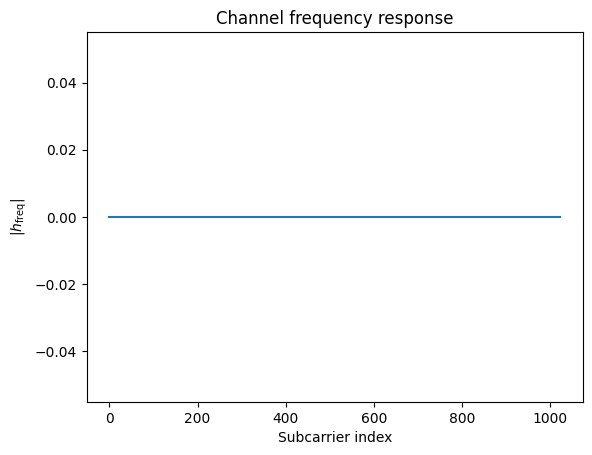

In [ ]:
# OFDM system parameters
num_subcarriers = 1024
subcarrier_spacing=30e3

# Compute frequencies of subcarriers relative to the carrier frequency
frequencies = subcarrier_frequencies(num_subcarriers, subcarrier_spacing)

# Compute channel frequency response
h_freq = paths.cfr(frequencies=frequencies,
                   normalize=True, # Normalize energy
                   normalize_delays=True,
                   out_type="numpy")

# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_time_steps, num_subcarriers]
print("Shape of h_freq: ", h_freq.shape)

# Plot absolute value
plt.figure()
plt.plot(np.abs(h_freq)[0,0,0,0,0,:]);
plt.xlabel("Subcarrier index");
plt.ylabel(r"|$h_\text{freq}$|");
plt.title("Channel frequency response");

Shape of taps:  (1, 2, 1, 16, 1, 107)


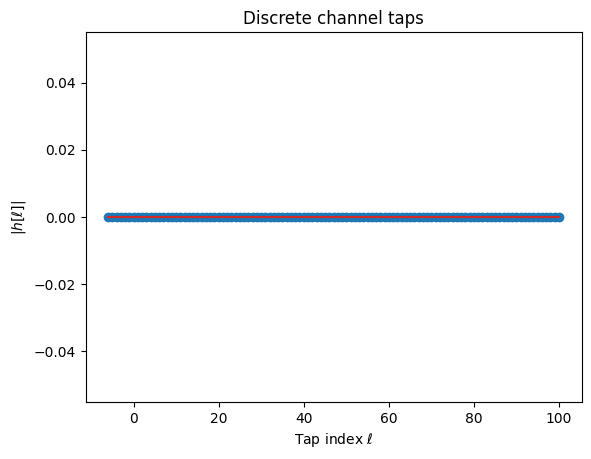

In [ ]:
taps = paths.taps(bandwidth=100e6, # Bandwidth to which the channel is low-pass filtered
                  l_min=-6,        # Smallest time lag
                  l_max=100,       # Largest time lag
                  sampling_frequency=None, # Sampling at Nyquist rate, i.e., 1/bandwidth
                  normalize=True,  # Normalize energy
                  normalize_delays=True,
                  out_type="numpy")
print("Shape of taps: ", taps.shape)

plt.figure()
plt.stem(np.arange(-6, 101), np.abs(taps)[0,0,0,0,0]);
plt.xlabel(r"Tap index $\ell$");
plt.ylabel(r"|$h[\ell]|$");
plt.title("Discrete channel taps");

⚠️ spectrum_to_matrix_4f: non-polarized Spectrum, using identity Jones fallback: drjit.llvm.ad.Float does not have a 'x' component.


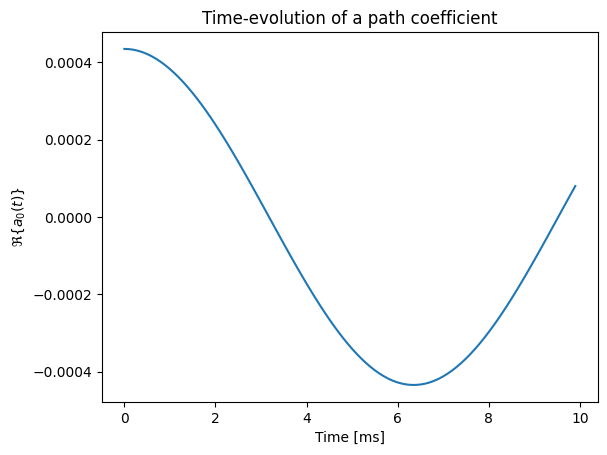

In [ ]:
scene.get("tx").velocity = [10, 0, 0]

# Recompute propagation paths
paths_mob = p_solver(scene=scene,
                     max_depth=5,
                     los=True,
                     specular_reflection=True,
                     diffuse_reflection=True,
                     refraction=True,
                     synthetic_array=True,
                     seed=41)

# Compute CIR with time-evolution
num_time_steps=100
sampling_frequency = 1e4
a_mob, _ = paths_mob.cir(sampling_frequency=sampling_frequency,
                         num_time_steps=num_time_steps,
                         out_type="numpy")

# Inspect time-evolution of a single path coefficient
plt.figure()
plt.plot(np.arange(num_time_steps)/sampling_frequency*1000,
         a_mob[0,0,0,0,0].real);
plt.xlabel("Time [ms]");
plt.ylabel(r"$\Re\{a_0(t) \}$");
plt.title("Time-evolution of a path coefficient");

In [ ]:
rm_solver = RadioMapSolver()

rm = rm_solver(scene=scene,
               max_depth=5,
               cell_size=[1,1],
               samples_per_tx=10**6)

⚠️ spectrum_to_matrix_4f: non-polarized Spectrum, using identity Jones fallback: drjit.llvm.ad.Float does not have a 'x' component.


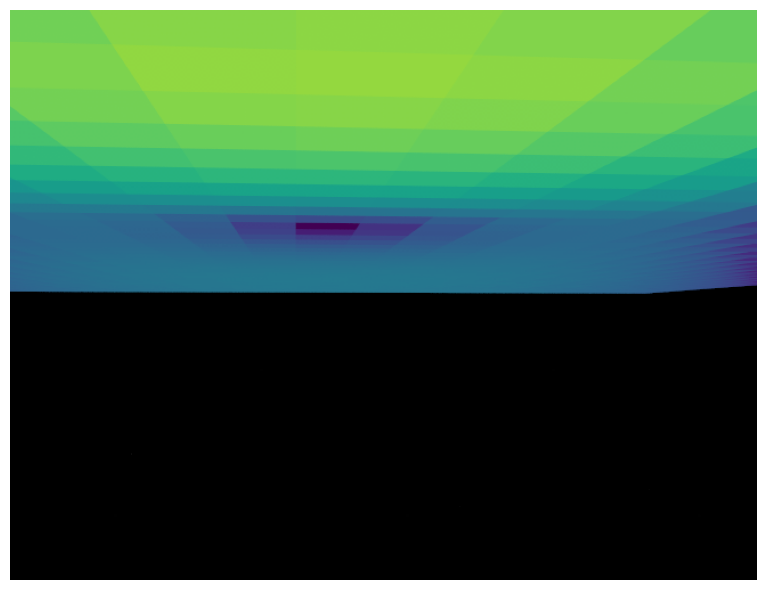

In [ ]:
if no_preview:
    scene.render(camera=my_cam, radio_map=rm);
else:
    scene.preview(radio_map=rm);